# Week 7 — Multi-Agent Systems
## From Conway to LangGraph: Agent Systems for Physicists in the LLM Era
### Università di Bologna — Dipartimento di Fisica

---

**What this notebook covers:**

| Section | Topic |
|---------|-------|
| 0 | Setup & imports |
| 1 | PettingZoo primer — `simple_spread` anatomy |
| 2 | Random baseline — establish metrics |
| 3 | Independent Learners (IL) with parameter sharing |
| 4 | IL with separate policies — manual training loop |
| 5 | Diagnosing cooperative failure — non-stationarity metrics |
| 6 | CTDE conceptual sketch — what MADDPG changes |
| 7 | Bridge to GABM — from reward to persona |

**Prerequisites:** Week 6 (Gymnasium, PPO, SB3). No new RL theory is introduced here.

> **Physics thread:** A single spin in an external field → interacting spin system.
> Mean-field theory as first diagnostic. CTDE ≡ mean-field training + local execution.


## Section 0 — Setup

In [1]:
# ── Install ────────────────────────────────────────────────────────────────
# Run once; takes ~60 s on Colab
!pip install "pettingzoo<=1.24.3" supersuit stable-baselines3 gymnasium torch --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.8/847.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 13.3 MB/s eta 0:00:00


In [2]:
import os
import warnings

os.environ["GYM_DISABLE_WARNINGS"] = "1"
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from pettingzoo.mpe import simple_spread_v3
import supersuit as ss
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecMonitor

print("All imports OK ✓")

All imports OK ✓


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Section 1 — PettingZoo Primer: `simple_spread` anatomy

`simple_spread_v3` is a **cooperative** Multi-Particle Environment (MPE):
- $N$ agents (blue circles) must cover $N$ landmarks (black crosses)
- Reward = $-\sum_\ell \min_i d(i, \ell)$  — penalises uncovered landmarks
- Observation: relative positions of landmarks + other agents (18-dim for N=3)
- Action: 5 discrete moves — idle, up, down, left, right

We use the **Parallel API**: all agents submit actions simultaneously,
mirroring a synchronous physical system.


## 🌍 Environment: `simple_spread` (PettingZoo MPE)

The `simple_spread` environment is a **cooperative multi-agent task** where:

- There are **N agents** (e.g., 3)
- There are **N landmarks** (targets in space)
- Agents must **spread out** to cover all landmarks

---

### 🎯 Objective
Minimize the distance between agents and landmarks.

This means agents must:
- Coordinate their movements
- Avoid collapsing onto the same location
- Efficiently cover the environment

---

### 🧠 Observations
Each agent observes:
- Its own position and velocity
- Relative positions of other agents
- Relative positions of landmarks

👉 Important: this is a **local observation** — agents do NOT see the full global state.

---

### 🎮 Actions
Discrete action space:
- Move: `up`, `down`, `left`, `right`
- Stay still

---

### 🏆 Reward (Cooperative)
All agents share the same reward, which is based on:
- Distance to landmarks (closer is better)
- Penalty for collisions between agents

👉 This is a **fully cooperative setting**:
all agents receive the **same global reward**

---

### ⚠️ Core Challenge
Agents must learn to:
- Coordinate **without explicit communication**
- Avoid selfish behavior
- Learn in a **non-stationary environment** (since other agents are learning too)

---

💡 This environment is ideal for studying:
- Cooperative Multi-Agent Reinforcement Learning
- Non-stationarity
- Emergent coordination

`parallel_env` is the key design choice: all agents act **simultaneously** at every step,
like a discrete-time physical system. The alternative is `AEC` (Agent Environment Cycle),
which is sequential. For `simple_spread` the Parallel API is natural: it is a synchronous system.

`reset()` returns a **dictionary** `observations`:

```python
{
  "agent_0": array(18,),
  "agent_1": array(18,),
  "agent_2": array(18,)
}
```

18 dimensions per agent = own position + own velocity + relative positions of the 2 other agents
+ relative positions of the 3 landmarks.

This is a **local observation** — no agent sees the global state.
"Local" does not mean "blind to others": it means a **partial and relative perspective**,
with no access to absolute coordinates or to the velocities and intended actions of other agents.

## The rollout loop

```python
actions = {
    agent: env.action_space(agent).sample()
    for agent in env.agents
}
```

**Random policy**: each agent samples uniformly from {0, 1, 2, 3, 4} = {idle, up, down, left, right}.
This is the **baseline to beat** — the zero measure of cooperative performance.

```python
observations, rewards, terminations, truncations, infos = env.step(actions)
```

`step()` takes the joint action dictionary and returns **5 dictionaries**, one entry per agent.

The crucial point is `rewards`: in `simple_spread` all three agents receive the **same scalar** at every step:

$$r_t = -\sum_{\ell=1}^{3} \min_{i} \, d(i, \ell)$$

This is a **fully cooperative reward**: there is no conflict of interest between agents.
The problem is purely one of coordination — agents must learn to spread out and cover all
landmarks, without any explicit communication.

## Termination condition

```python
if all(terminations.values()) or all(truncations.values()):
    break
```

In `simple_spread` episodes end **only by truncation** — `max_cycles=25` by default — not by
natural termination. This condition is therefore almost always triggered by `truncations`,
not by `terminations`.

This is worth pointing out explicitly: the Gymnasium distinction between
`terminated` (absorbing state, e.g. CartPole falling over) and
`truncated` (artificial time limit) carries over directly into the multi-agent setting.

Each is a dictionary keyed by agent name, just like `observations` and `rewards`.

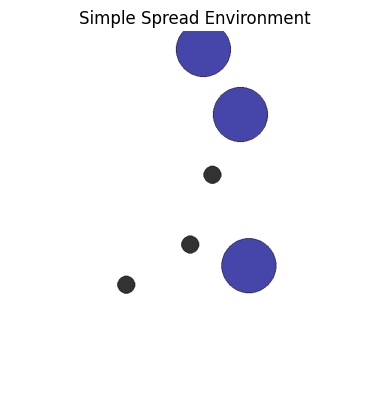

In [6]:
from pettingzoo.mpe import simple_spread_v3
import matplotlib.pyplot as plt

env = simple_spread_v3.parallel_env(render_mode="rgb_array")
observations, infos = env.reset(seed=40)

frames = []

for step in range(25):
    actions = {
        agent: env.action_space(agent).sample()
        for agent in env.agents
    }

    observations, rewards, terminations, truncations, infos = env.step(actions)

    frame = env.render()
    frames.append(frame)

    if all(terminations.values()) or all(truncations.values()):
        break

env.close()

plt.imshow(frames[-1])
plt.axis("off")
plt.title("Simple Spread Environment")
plt.show()

## Accessing the internal world state: `env.unwrapped`

PettingZoo (like Gymnasium) wraps the core environment in several **wrapper layers**
that add logging, observation preprocessing, and API compliance checks.

```python
world = env.unwrapped.world
```

`.unwrapped` strips all wrappers and returns the **raw environment object** —
in MPE this exposes `world`, a `World` instance containing the full physical state:

```python
world.agents     # list of Agent objects  →  .state.p_pos, .state.p_vel
world.landmarks  # list of Landmark objects  →  .state.p_pos  (fixed)
```

This is the **global state** that no individual agent can observe during execution,
but that we — as experimenters — can read directly.

> **Why this matters for the course:**
> `world` is exactly what the **centralised critic** in MADDPG has access to during
> training. Individual agents only see their local `observations` dictionary.
> Reading `world` directly is how we build our custom visualisation with truly fixed
> landmark positions — bypassing the visual drift in the built-in `rgb_array` renderer.

## The rollout loop

```python
for step in range(40):
```
We run for at most 40 steps. The episode will end earlier if `max_cycles=25` is reached
(truncation) — the `break` at the bottom handles this.
More elegan: *for step in range(env.unwrapped.max_cycles):*

---

```python
    pos = np.array([a.state.p_pos.copy() for a in world.agents])
    agent_positions.append(pos)
```
We read agent positions **before** `env.step()` — this is the state the agents are
currently in. `.copy()` is essential: `p_pos` is a mutable numpy array and would be
overwritten in place by the physics engine at the next step.

---

```python
    actions = {agent: env.action_space(agent).sample() for agent in env.agents}
```
This builds the **joint action dictionary** required by the Parallel API.

Two things to notice:

- `env.agents` is a **live list**: PettingZoo removes an agent from it the moment it
  terminates or is truncated. Iterating over `env.agents` (not a fixed list) ensures
  we never try to submit an action for a dead agent.

- `env.action_space(agent).sample()` draws **independently and uniformly** from
  {0, 1, 2, 3, 4} for each agent. There is zero coordination — this is precisely
  why the random baseline performs poorly. A fully coordinated policy would need to
  break the symmetry and assign different landmark targets to different agents.

---

```python
    reward_history.append(list(rewards.values())[0])
```
Since all agents share the same scalar reward in `simple_spread`, we only need
to store one value per step. `list(rewards.values())[0]` picks the first entry
of the reward dictionary — all three would be identical.

In [13]:
from pettingzoo.mpe import simple_spread_v3
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

env = simple_spread_v3.parallel_env()
observations, infos = env.reset(seed=42)
world = env.unwrapped.world

# Landmark positions — fixed for the entire episode
landmark_pos = np.array([lm.state.p_pos.copy() for lm in world.landmarks])
print("Landmark positions (fixed):")
for i, p in enumerate(landmark_pos):
    print(f"  Landmark {i}: {p}")

# Collect agent positions at every step
agent_positions = []
reward_history = []

for step in range(40):
    pos = np.array([a.state.p_pos.copy() for a in world.agents])
    agent_positions.append(pos)

    actions = {agent: env.action_space(agent).sample() for agent in env.agents}
    observations, rewards, terminations, truncations, infos = env.step(actions)
    reward_history.append(list(rewards.values())[0])

    if all(terminations.values()) or all(truncations.values()):
        break

env.close()

# Animation
AGENT_COLORS = ["#4A9ECC", "#E8B931", "#4ACC7A"]
WORLD_RANGE   = 1.5

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(-WORLD_RANGE, WORLD_RANGE)
ax.set_ylim(-WORLD_RANGE, WORLD_RANGE)
ax.set_aspect("equal")
ax.set_facecolor("#F5F5F5")
ax.set_title("simple_spread — random policy", fontweight="bold")

# Draw landmarks ONCE as fixed black crosses
for i, pos in enumerate(landmark_pos):
    ax.plot(*pos, "kx", markersize=14, markeredgewidth=2.5,
            label="landmark" if i == 0 else "")

# Animated agent markers
agent_dots = [
    ax.plot([], [], "o", color=AGENT_COLORS[i],
            markersize=14, alpha=0.85,
            label=f"agent {i}")[0]
    for i in range(len(agent_positions[0]))
]

step_text = ax.text(0.03, 0.95, "", transform=ax.transAxes,
                    fontsize=10, va="top")
rew_text  = ax.text(0.03, 0.88, "", transform=ax.transAxes,
                    fontsize=9, color="#888888", va="top")

ax.legend(loc="upper right", fontsize=8)

def update(idx):
    pos = agent_positions[idx]
    for i, dot in enumerate(agent_dots):
        dot.set_data([pos[i, 0]], [pos[i, 1]])
    step_text.set_text(f"step {idx}")
    rew_text.set_text(f"reward: {reward_history[idx]:.2f}")
    return agent_dots + [step_text, rew_text]

ani = animation.FuncAnimation(
    fig, update,
    frames=len(agent_positions),
    interval=200,
    blit=True
)

plt.tight_layout()
plt.close()
HTML(ani.to_jshtml())

Landmark positions (fixed):
  Landmark 0: [0.5222794  0.57212861]
  Landmark 1: [-0.74377273 -0.09922812]
  Landmark 2: [-0.25840395  0.85352998]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 🔍 Understanding the Environment Output

- **Agents**:  
  `['agent_0', 'agent_1', 'agent_2']` → three independent decision-makers acting in parallel.

- **Observation (shape = 18)**:  
  Each agent receives a vector of 18 values containing:
  - Its own **velocity (2)** and **position (2)**
  - **Relative positions of landmarks (6)**
  - **Relative positions of other agents (4)**
  - **Communication (4)** → not used here (all zeros)

👉 All information is **relative**, not global.

- **Action space: `Discrete(5)`**  
  Each agent can:
  - Stay
  - Move left / right / up / down

---

### ⚠️ Key idea

Each agent only sees a **local, partial view of the world**.  
There is no central controller → coordination must **emerge from learning**.

---

💡 This is why multi-agent RL is hard:
- Agents observe limited information  
- Other agents are also moving (and learning)  
→ the environment becomes **non-stationary**

In [14]:
# ── Inspect the environment ───────────────────────────────────────────────
env = simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False)
obs, infos = env.reset(seed=42)

print("Agents:", env.agents)
print()
for a in env.agents:
    print(f"  {a}  obs shape: {obs[a].shape}  "
          f"action_space: {env.action_space(a)}")
print()
print("Observation sample (agent_0):")
print(np.round(obs["agent_0"], 3))


Agents: ['agent_0', 'agent_1', 'agent_2']

  agent_0  obs shape: (18,)  action_space: Discrete(5)
  agent_1  obs shape: (18,)  action_space: Discrete(5)
  agent_2  obs shape: (18,)  action_space: Discrete(5)

Observation sample (agent_0):
[ 0.     0.     0.548 -0.122 -0.026  0.694 -1.292  0.023 -0.806  0.976
  0.169  0.517 -1.36   1.073  0.     0.     0.     0.   ]


## Random baseline — measuring zero-coordination performance

### `run_episode` — a reusable rollout function

```python
def run_episode(env, policy_fn, seed=0):
    obs, _ = env.reset(seed=seed)
    total_rewards = defaultdict(float)
    step_rewards  = []

    while env.agents:
        actions = {a: policy_fn(a, obs[a]) for a in env.agents}
        obs, rew, term, trunc, _ = env.step(actions)
        step_rewards.append(sum(rew.values()) / len(rew))
        for a, r in rew.items():
            total_rewards[a] += r

    return total_rewards, step_rewards
```

`policy_fn` is a **callable** with signature `(agent_id, observation) → action`.
Passing the policy as an argument makes `run_episode` reusable across all sections:
random baseline, IL-PPO, IL-REINFORCE, and eventually MADDPG — same loop, different policy.

`while env.agents` is the canonical PettingZoo idiom: the list shrinks as agents
terminate or are truncated, and the loop exits cleanly when it is empty.

`step_rewards` stores the **mean reward across agents at each step** — a single scalar
per timestep. Since all agents share the same reward in `simple_spread`, this is
equivalent to storing any individual agent's reward, but the averaging makes the
code robust to environments with heterogeneous rewards.

---

### `random_policy` — the zero-coordination baseline

```python
def random_policy(agent, observation):
    return env.action_space(agent).sample()
```

The observation is **ignored entirely**: each agent samples uniformly from
{0, 1, 2, 3, 4} with no memory and no coordination.
This is the performance floor. Any learning algorithm that fails to
beat this number is not working.

---

### Interpreting the output

All three agents return **the same total reward** (up to floating point) —
a direct consequence of the shared cooperative reward signal.
The mean over agents is therefore the same number, but we print all three
as a sanity check: if they differ significantly, something is wrong with
the environment setup.

The expected value for a random policy is approximately **−27 per episode**
(3 agents × 25 steps, landmarks almost never covered).
This is the reference point for all subsequent sections.

```python
total_rewards = defaultdict(float)
```

`defaultdict(float)` is a standard Python dictionary with one extra rule:
if you access a key that does not exist yet, it is created automatically
with a default value of `0.0`.

This means the accumulation line:

```python
total_rewards[a] += r
```

works safely on the **first step** — without needing to initialise
`total_rewards["agent_0"] = 0.0` beforehand.
With a plain `dict` this would raise a `KeyError`.

The agent names (`"agent_0"`, `"agent_1"`, `"agent_2"`) are only known
at runtime, so `defaultdict(float)` is the natural choice here.

A plain-dict equivalent would require an explicit initialisation:

```python
total_rewards = {a: 0.0 for a in env.possible_agents}
```

Both are correct — `defaultdict` is simply more concise when keys
are discovered incrementally during the loop.

```python
actions = {a: policy_fn(a, obs[a]) for a in env.agents}
```

A dictionary comprehension that builds the **joint action dictionary**
required by the PettingZoo Parallel API in one line.

For each active agent `a`, it calls:

```python
policy_fn(a, obs[a])
```

- `a` — the agent identifier (`"agent_0"`, `"agent_1"`, `"agent_2"`)
- `obs[a]` — that agent's **local observation**, a numpy array of shape `(18,)`

The result is:

```python
{
  "agent_0": 3,   # e.g. move left
  "agent_1": 0,   # e.g. idle
  "agent_2": 1,   # e.g. move up
}
```

which is passed as a single object to `env.step()`.

Two design choices worth noting:

**`env.agents` not `env.possible_agents`** — `env.agents` is the live list
of agents still active in the current step. If an agent has already terminated
or been truncated, it is no longer in `env.agents` and we do not
try to compute an action for it. `env.possible_agents` is the full static
list regardless of status — using it here would cause a `KeyError` on `obs[a]`.

**`policy_fn(a, obs[a])` not just `policy_fn(obs[a])`** — passing the agent
identity `a` as the first argument allows the policy to behave differently
per agent. The random baseline ignores it, but a trained policy with
separate parameters for each agent needs it to select the right network.

In [15]:
def run_episode(env, policy_fn, seed=0):
    """Run one episode; return per-step rewards and final collision count."""
    obs, _ = env.reset(seed=seed)
    total_rewards = defaultdict(float)
    step_rewards  = []

    while env.agents:
        actions = {a: policy_fn(a, obs[a]) for a in env.agents}
        obs, rew, term, trunc, _ = env.step(actions)
        step_rewards.append(sum(rew.values()) / len(rew))
        for a, r in rew.items():
            total_rewards[a] += r

    return total_rewards, step_rewards


def random_policy(agent, observation):
    return env.action_space(agent).sample()


env = simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False)
totals, steps = run_episode(env, random_policy, seed=0)

print("Episode total rewards (random policy):")
for a, r in totals.items():
    print(f"  {a}: {r:.3f}")
print(f"  Mean: {np.mean(list(totals.values())):.3f}")


Episode total rewards (random policy):
  agent_0: -27.644
  agent_1: -27.644
  agent_2: -27.644
  Mean: -27.644


## 🎲 Random Policy – Episode Output

All agents receive the **same total reward**:

- `agent_0 = agent_1 = agent_2 =-  27.644`

👉 This is because the environment is **fully cooperative**:  
there is a **shared global reward** for the whole team.

---

### 📉 Why is the reward negative?

- Agents are **far from landmarks**
- No coordination (random actions)
- Possible collisions

---

### 📊 Interpretation

- Total episode reward ≈ **-30**
- Episode length = 25 steps  
→ per-step reward ≈ **-1.2**

---

### 💡 Key idea

This is the **random baseline**:
agents behave randomly → poor performance → no coordination.

## Random baseline — 20 episodes

Each bar is one episode. The height is the **mean reward per step**:

$$\bar{r}_{\text{ep}} = \frac{1}{25} \sum_{t=1}^{25} r_t$$

The dashed yellow line is the mean across all 20 episodes — saved as `RANDOM_BASELINE`
and used as the reference point for every algorithm in the sections that follow.

---

Three things to notice:

**Bars vary little across episodes.** Each bar is already an average over 25 steps,
so the Central Limit Theorem suppresses fluctuations. A plot of single-step rewards
would show much more noise.

**All bars are negative.** By construction: the reward
$r_t = -\sum_\ell \min_i d(i,\ell)$ is always $\leq 0$,
and equals $0$ only if every landmark is covered exactly — a measure-zero event
under a random policy.

**`RANDOM_BASELINE` is the benchmark.** In every subsequent section
(IL with parameter sharing, IL with separate policies, MADDPG),
learning curves are meaningful only relative to this number.
An algorithm that fails to beat `RANDOM_BASELINE` has learned nothing useful.

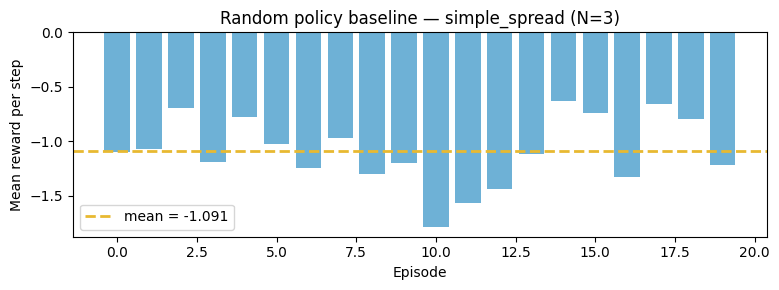

Random baseline: -1.0912


In [16]:
# ── Visualise one episode (reward per step) ──────────────────────────────
n_episodes = 20
ep_means = []
for ep in range(n_episodes):
    _, steps = run_episode(
        simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False),
        random_policy, seed=ep)
    ep_means.append(np.mean(steps))

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(n_episodes), ep_means, color="#4A9ECC", alpha=0.8)
ax.axhline(np.mean(ep_means), color="#E8B931", lw=2, ls="--",
           label=f"mean = {np.mean(ep_means):.3f}")
ax.set_xlabel("Episode")
ax.set_ylabel("Mean reward per step")
ax.set_title("Random policy baseline — simple_spread (N=3)")
ax.legend()
plt.tight_layout()
plt.show()

RANDOM_BASELINE = np.mean(ep_means)
print(f"Random baseline: {RANDOM_BASELINE:.4f}")


## 🎬 What is an Episode?

An **episode** is one complete run of the environment, from start to finish.

---

### 🔁 Episode structure

1. **Reset**
   - Environment is initialized  
   - Agents and landmarks are placed

2. **Steps (interaction loop)**
   - At each step:
     - All agents choose an action
     - The environment updates
     - Rewards are assigned

3. **Termination**
   - Episode ends after a fixed number of steps  
   - Here: `max_cycles = 25`

---

### 📊 In this setup

- **1 episode = up to 25 steps**
- At each step:
  - All 3 agents act simultaneously
- We measure:
  - **Step reward** → reward at each step  
  - **Total reward** → sum over the episode  

---

### 💡 Intuition

> An episode is like one full game:  
agents repeatedly observe, act, and receive rewards until the game ends.

---

### ⚠️ Key distinction

- **Step** = one action + reward  
- **Episode** = sequence of steps

## Section 2 — Why Independent Learners break: a quick derivation

From each agent $i$'s perspective the effective transition kernel is:

$$P(s' \mid s, a_i) = \sum_{a_{-i}} P(s' \mid s, \mathbf{a})\, \pi_{-i}(a_{-i} \mid s)$$

This kernel is **not stationary** as long as other agents' policies $\pi_{-i}$ are updating.
Three concrete consequences:

1. **Bellman invalidity** — $Q^*(s, a_i)$ implicitly depends on $\pi_{-i}$; solving the
   Bellman equation for one set of policies produces a wrong $Q$ when others change.

2. **Replay buffer poisoning** — old transitions $(s, a, r, s')$ were generated under
   older $\pi_{-i}$; replaying them introduces bias proportional to the policy shift.

3. **Credit assignment noise** — in a cooperative task the shared reward
   $r = \sum_i r_i$ makes it impossible to attribute improvement to a specific
   agent's action.

---

**Physics analogy.** Each agent tries to minimise its local free energy:

$$\mathcal{F}_i = \mathbb{E}[-r_i] + \beta^{-1} H(\pi_i)$$

but the landscape $\mathcal{F}_i$ itself deforms as other agents update.
This is the MARL analogue of a **non-equilibrium system** where the Hamiltonian
evolves faster than the dynamics can relax — there is no guarantee of convergence
to any fixed point.

---
## Section 3 — IL with parameter sharing (SuperSuit + SB3 PPO)

The simplest IL variant: all agents share a **single** policy network.
`supersuit.pettingzoo_env_to_vec_env_v1` stacks all agents as parallel
"copies" of the same Gym environment — SB3 PPO treats them as a vectorised
single-agent problem.

This is equivalent to: every agent runs the same PPO update on its local
$(o_i, a_i, r_i)$ — no communication, no shared value function.

Advantage: dead-simple to implement with SB3.
Limitation: identical parameters for all agents; cannot specialise.


## Reading the SB3 PPO training log

SB3 prints a log table at every rollout collection cycle. Here is what each field means.

---

### `rollout/` — environment statistics

**`ep_len_mean = 25`** — all episodes last exactly 25 steps. Termination always comes
from truncation (`max_cycles`), never from a natural terminal state.

**`ep_rew_mean`** — mean episode reward. This is the number that matters.
The random baseline was ≈ **−27.6**: values above this mean the policy is learning
something useful. Progress is slow and noisy — expected in multi-agent IL.

---

### `time/` — training throughput

**`total_timesteps`** — total environment steps so far. This is the correct axis
for comparing algorithms: with N=3 agents and parameter sharing, each env-step
generates 3 experiences for the buffer.

**`iterations`** — number of collect → update cycles completed.

---

### `train/` — optimiser diagnostics

**`approx_kl`** — approximate KL divergence between the old and new policy.
PPO uses this as an early-stopping signal: if it exceeds a threshold (~0.01–0.02)
updates are interrupted. Values around 0.006 indicate stable, conservative updates.

**`clip_fraction`** — fraction of gradient steps that hit the PPO clip boundary
($\epsilon = 0.2$). Low values mean the policy is not making large jumps.
Values above 0.3 would signal instability.

**`entropy_loss`** — policy entropy (negated, because SB3 maximises it).
A constant value across log entries means the policy is neither collapsing
to determinism nor exploding to pure noise.
In physics terms: the effective temperature of the policy is stable.

**`explained_variance`** — how well the value function predicts the actual return.
Ranges from 0 (useless) to 1 (perfect). Values around **0.2 are low**:
with parameter sharing the critic sees observations from different agents
as if they were equivalent, but they are not. This is a direct symptom
of the non-stationarity problem.

**`value_loss`** — MSE between predicted value and actual return.
Should decrease over time if the critic is learning.

---

### The overall signal

`ep_rew_mean` rising from −23.8 to −21.3 over ~3000 timesteps confirms that learning
is happening, but slowly and noisily. The root cause is **replay buffer poisoning**:
experiences collected under earlier policies of the other agents are still in the
buffer, introducing a bias that grows with the policy shift.

In [11]:
def make_shared_policy_env(n_agents=3, max_cycles=25, seed=0):
    """
    Wrap simple_spread for SB3 PPO with parameter sharing.
    supersuit.pettingzoo_env_to_vec_env stacks N agents as N envs.
    """
    env = simple_spread_v3.parallel_env(
        N=n_agents, max_cycles=max_cycles, continuous_actions=False)
    env = ss.pad_observations_v0(env)
    env = ss.pad_action_space_v0(env)
    env = ss.pettingzoo_env_to_vec_env_v1(env)   # N parallel envs
    env = ss.concat_vec_envs_v1(env, 1, base_class="stable_baselines3")
    env = VecMonitor(env)
    return env


# ── Train ────────────────────────────────────────────────────────────────
TOTAL_STEPS_SHARED = 200_000   # increase for better convergence

train_env = make_shared_policy_env()

# Patch compatibility: SuperSuit ConcatVecEnv lacks .seed()
if not hasattr(train_env, "seed"):
    train_env.seed = lambda seed=None: [seed] * train_env.num_envs

if not hasattr(train_env, "set_options"):
    train_env.set_options = lambda options=None: None

model_shared = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=256,
    gamma=0.95,
    verbose=1,
)

print("Training shared-policy IL (parameter sharing)…")
model_shared.learn(total_timesteps=TOTAL_STEPS_SHARED)
print("Done ✓")


Using cpu device
Training shared-policy IL (parameter sharing)…


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 25       |
|    ep_rew_mean     | -28      |
| time/              |          |
|    fps             | 1204     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 3072     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 25          |
|    ep_rew_mean          | -25.5       |
| time/                   |             |
|    fps                  | 1285        |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.006605902 |
|    clip_fraction        | 0.0262      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.61       |
|    explained_variance   | -0.0196     |
|    learning_rate        | 0.

In [12]:
# ── Evaluate shared policy ───────────────────────────────────────────────
def eval_sb3_model(model, n_episodes=30, n_agents=3, max_cycles=25):
    """
    Evaluate a trained SB3 model on raw PettingZoo env.
    Returns list of mean episode rewards.
    """
    ep_rewards = []
    eval_env = simple_spread_v3.parallel_env(
        N=n_agents, max_cycles=max_cycles, continuous_actions=False)

    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=ep + 1000)
        ep_r = 0.0
        steps = 0
        while eval_env.agents:
            actions = {}
            for a in eval_env.agents:
                o = obs[a].reshape(1, -1)
                action, _ = model.predict(o, deterministic=True)
                actions[a] = int(action[0])
            obs, rew, term, trunc, _ = eval_env.step(actions)
            ep_r += sum(rew.values()) / max(len(rew), 1)
            steps += 1
        ep_rewards.append(ep_r / max(steps, 1))

    return ep_rewards


shared_rewards = eval_sb3_model(model_shared, n_episodes=30)
print(f"Shared-policy IL  mean reward: {np.mean(shared_rewards):.4f}  "
      f"±{np.std(shared_rewards):.4f}")
print(f"Random baseline              : {RANDOM_BASELINE:.4f}")
print(f"Improvement over random: "
      f"{(np.mean(shared_rewards) - RANDOM_BASELINE) / abs(RANDOM_BASELINE) * 100:.1f}%")


Shared-policy IL  mean reward: -0.8280  ±0.2459
Random baseline              : -1.1276
Improvement over random: 26.6%


---
## Section 4 — IL with separate policies: manual training loop

Here each agent maintains its own independent policy network (no sharing).
We implement a minimal **actor-only REINFORCE** loop to keep the code
readable and the non-stationarity signal visible.

This is not the most efficient algorithm — the goal is to expose the
training dynamics so we can measure the failure mode in Section 5.


In [ ]:
# ── Minimal policy network ───────────────────────────────────────────────
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)

    def act(self, obs_np):
        x = torch.tensor(obs_np, dtype=torch.float32).unsqueeze(0)
        probs = self(x)
        dist  = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)


def discount_returns(rewards, gamma=0.95):
    G, returns = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


In [ ]:
# ── Training loop — separate policies ────────────────────────────────────
N_AGENTS   = 3
N_EPISODES = 600        # increase for better convergence (~2 min on Colab)
GAMMA      = 0.95
LR         = 3e-4
EVAL_EVERY = 50

env_sep = simple_spread_v3.parallel_env(N=N_AGENTS, max_cycles=25,
                                        continuous_actions=False)
obs_dim   = env_sep.observation_space("agent_0").shape[0]
n_actions = env_sep.action_space("agent_0").n

# One independent policy per agent
policies   = {f"agent_{i}": PolicyNet(obs_dim, n_actions) for i in range(N_AGENTS)}
optimisers = {a: optim.Adam(p.parameters(), lr=LR) for a, p in policies.items()}

# Tracking
train_rewards  = []          # mean episode reward across agents
reward_var_log = []          # variance across agents per episode (non-stationarity proxy)

for ep in range(N_EPISODES):
    obs, _ = env_sep.reset(seed=ep)
    ep_log_probs  = defaultdict(list)
    ep_rewards_ag = defaultdict(list)

    # ── Roll out one episode ────────────────────────────────────────────
    while env_sep.agents:
        actions = {}
        log_ps  = {}
        for a in env_sep.agents:
            action, lp = policies[a].act(obs[a])
            actions[a] = action
            log_ps[a]  = lp
        obs, rew, term, trunc, _ = env_sep.step(actions)
        for a in list(log_ps.keys()):
            ep_log_probs[a].append(log_ps[a])
            ep_rewards_ag[a].append(rew.get(a, 0.0))

    # ── REINFORCE update for each agent ────────────────────────────────
    for a in policies:
        if not ep_log_probs[a]:
            continue
        returns  = discount_returns(ep_rewards_ag[a], GAMMA)
        log_probs = torch.stack(ep_log_probs[a])
        loss = -(log_probs * returns).mean()
        optimisers[a].zero_grad()
        loss.backward()
        optimisers[a].step()

    # ── Logging ────────────────────────────────────────────────────────
    mean_ep = np.mean([sum(ep_rewards_ag[a]) for a in policies])
    var_ep  = np.var( [sum(ep_rewards_ag[a]) for a in policies])
    train_rewards.append(mean_ep)
    reward_var_log.append(var_ep)

    if (ep + 1) % EVAL_EVERY == 0:
        recent = np.mean(train_rewards[-EVAL_EVERY:])
        print(f"  ep {ep+1:4d}/{N_EPISODES}  "
              f"mean reward: {recent:6.3f}  "
              f"reward var: {np.mean(reward_var_log[-EVAL_EVERY:]):.4f}")

print("Training done ✓")


  ep   50/600  mean reward: -25.550  reward var: 0.1211
  ep  100/600  mean reward: -26.047  reward var: 0.1067
  ep  150/600  mean reward: -28.603  reward var: 0.1700
  ep  200/600  mean reward: -28.409  reward var: 0.1944
  ep  250/600  mean reward: -27.060  reward var: 0.1833
  ep  300/600  mean reward: -26.705  reward var: 0.2744
  ep  350/600  mean reward: -27.391  reward var: 0.1678
  ep  400/600  mean reward: -26.661  reward var: 0.1911
  ep  450/600  mean reward: -26.236  reward var: 0.1722
  ep  500/600  mean reward: -26.194  reward var: 0.1522
  ep  550/600  mean reward: -25.363  reward var: 0.1489
  ep  600/600  mean reward: -28.177  reward var: 0.1678
Training done ✓


---
## Section 5 — Diagnosing cooperative failure

We use three metrics to characterise the failure mode of IL:

1. **Mean episode reward** — overall performance vs random baseline.
2. **Between-agent reward variance** — measures how asymmetric learning is.
   High variance → one agent is "lazy" or stuck.  
   In a well-coordinated team this should be near zero.
3. **Learning curve smoothness** — non-stationarity manifests as oscillation;
   a well-converging single-agent problem has monotone improvement.

> **Physics analogy.** Reward variance across agents is the order parameter
> analogue: zero in the ferromagnetic (cooperative) phase, large in the
> disordered phase. The transition between the two is driven by the coupling
> strength (shared reward signal).


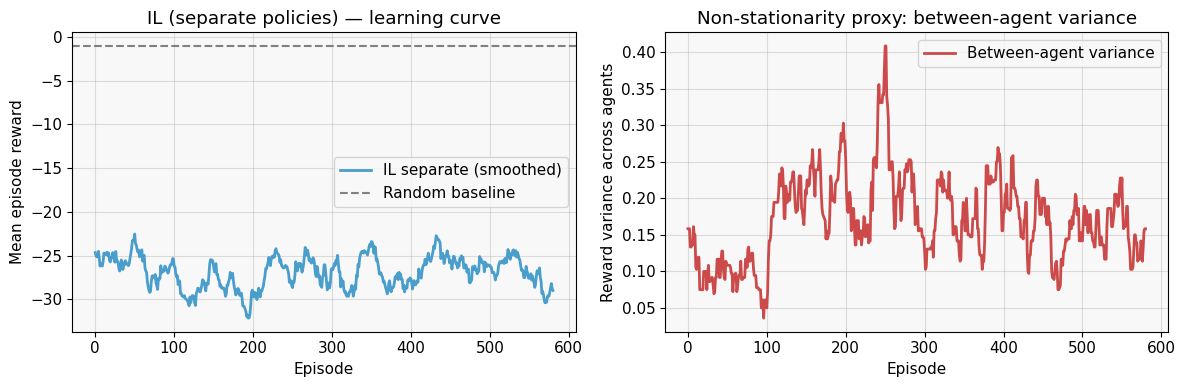

Final 50-ep mean reward : -28.1766
Final 50-ep reward var  : 0.1678
Random baseline         : -1.0146


In [ ]:
# ── Smooth helper ───────────────────────────────────────────────────────
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

# ── Plot 1: learning curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(smooth(train_rewards), color="#4A9ECC", lw=2, label="IL separate (smoothed)")
ax.axhline(RANDOM_BASELINE, color="gray", ls="--", lw=1.5, label="Random baseline")
ax.set_xlabel("Episode")
ax.set_ylabel("Mean episode reward")
ax.set_title("IL (separate policies) — learning curve")
ax.legend()

ax = axes[1]
ax.plot(smooth(reward_var_log), color="#CC4A4A", lw=2, label="Between-agent variance")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward variance across agents")
ax.set_title("Non-stationarity proxy: between-agent variance")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Final 50-ep mean reward : {np.mean(train_rewards[-50:]):.4f}")
print(f"Final 50-ep reward var  : {np.mean(reward_var_log[-50:]):.4f}")
print(f"Random baseline         : {RANDOM_BASELINE:.4f}")


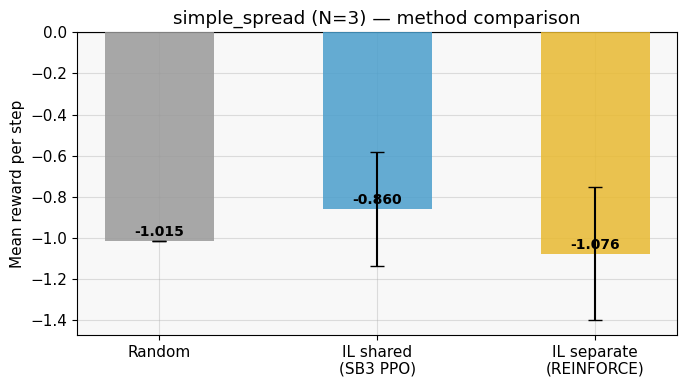

In [ ]:
# ── Plot 2: compare random vs IL shared vs IL separate ───────────────────
def eval_separate_policies(policies, n_episodes=30):
    ev = simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False)
    ep_rewards = []
    for ep in range(n_episodes):
        obs, _ = ev.reset(seed=ep + 2000)
        ep_r, steps = 0.0, 0
        while ev.agents:
            actions = {}
            for a in ev.agents:
                if a in policies:
                    action, _ = policies[a].act(obs[a])
                    actions[a] = action
                else:
                    actions[a] = ev.action_space(a).sample()
            obs, rew, _, _, _ = ev.step(actions)
            ep_r += sum(rew.values()) / max(len(rew), 1)
            steps += 1
        ep_rewards.append(ep_r / max(steps, 1))
    return ep_rewards


sep_rewards = eval_separate_policies(policies, n_episodes=30)

labels = [
    "Random",
    "IL shared\n(SB3 PPO)",
    "IL separate\n(REINFORCE)"
]
means   = [RANDOM_BASELINE,
           np.mean(shared_rewards),
           np.mean(sep_rewards)]
stds    = [np.std([]),
           np.std(shared_rewards),
           np.std(sep_rewards)]
colors  = ["#999999", "#4A9ECC", "#E8B931"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, means, color=colors, alpha=0.85, width=0.5, zorder=3)
ax.errorbar(labels, means, yerr=[0, stds[1], stds[2]],
            fmt='none', color='black', capsize=5, lw=1.5, zorder=4)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel("Mean reward per step")
ax.set_title("simple_spread (N=3) — method comparison")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.01,
            f"{m:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


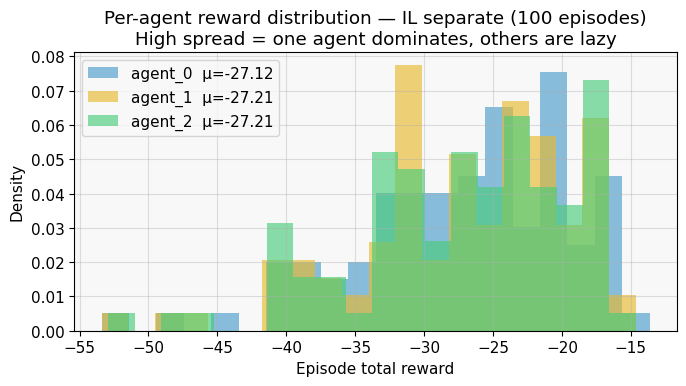


Between-agent reward std (higher = more asymmetric / broken cooperation):
  {'agent_0': np.float64(-27.115331669522647), 'agent_1': np.float64(-27.21033166952265), 'agent_2': np.float64(-27.21033166952265)}
  std across agents: 0.0448


In [ ]:
# ── Plot 3: per-agent reward distribution (last 100 episodes) ────────────
per_agent = defaultdict(list)
env_diag = simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False)

for ep in range(100):
    obs, _ = env_diag.reset(seed=ep + 5000)
    totals = defaultdict(float)
    while env_diag.agents:
        actions = {}
        for a in env_diag.agents:
            if a in policies:
                action, _ = policies[a].act(obs[a])
                actions[a] = action
            else:
                actions[a] = env_diag.action_space(a).sample()
        obs, rew, _, _, _ = env_diag.step(actions)
        for a, r in rew.items():
            totals[a] += r
    for a, r in totals.items():
        per_agent[a].append(r)

fig, ax = plt.subplots(figsize=(7, 4))
agent_colors = ["#4A9ECC", "#E8B931", "#4ACC7A"]
for i, (a, rs) in enumerate(per_agent.items()):
    ax.hist(rs, bins=20, alpha=0.65, color=agent_colors[i],
            label=f"{a}  μ={np.mean(rs):.2f}", density=True)
ax.set_xlabel("Episode total reward")
ax.set_ylabel("Density")
ax.set_title(
    "Per-agent reward distribution — IL separate (100 episodes)\n"
    "High spread = one agent dominates, others are lazy"
)
ax.legend()
plt.tight_layout()
plt.show()

print("\nBetween-agent reward std (higher = more asymmetric / broken cooperation):")
agent_means = {a: np.mean(rs) for a, rs in per_agent.items()}
print(f"  {agent_means}")
print(f"  std across agents: {np.std(list(agent_means.values())):.4f}")


---
## Section 6 — CTDE: what MADDPG changes

**Centralised Training, Decentralised Execution (CTDE)** is the architectural
fix for the non-stationarity problem.

### What changes in the critic

In IL, agent $i$ has a value function $V_{\phi_i}(o_i)$ — it can only see
its own observation.

In MADDPG the critic is **centralised**:

$$Q_{\phi_i}(\underbrace{o_1,\ldots,o_N}_{\text{global obs}},
               \underbrace{a_1,\ldots,a_N}_{\text{joint action}})$$

This critic is only used **during training** to compute a stable advantage
estimate. At execution time each agent still uses only $o_i$.

### Why this fixes non-stationarity

Because the centralised critic conditions on **all** agents' current actions,
it sees $\pi_{-i}$ explicitly — the environment looks stationary from the
critic's perspective.

### Physics analogy

| | Single-agent | IL | CTDE |
|---|---|---|---|
| Critic | $V(o_i)$ | $V_{\phi_i}(o_i)$ | $Q_{\phi_i}(\mathbf{o}, \mathbf{a})$ |
| Effective field | external $h$ | noisy $h_i^\text{eff}$ (shifting) | correct $h_i^\text{eff}$ (stable) |
| Actor | $\pi(o_i)$ | $\pi_{\theta_i}(o_i)$ | $\pi_{\theta_i}(o_i)$ — same! |

The actor is identical in IL and CTDE.
Only the training signal changes.


In [ ]:
# ── MADDPG critic architecture (skeleton) ────────────────────────────────
class MADDPGCritic(nn.Module):
    """
    Centralised critic for agent i.
    Input: concatenation of ALL agents' observations + ALL agents' actions.
    Output: scalar Q-value for agent i.

    At execution time this network is discarded — only the actor runs.
    """
    def __init__(self, n_agents, obs_dim, n_actions, hidden=128):
        super().__init__()
        # Joint input dimension: all obs + all one-hot actions
        joint_dim = n_agents * obs_dim + n_agents * n_actions
        self.net = nn.Sequential(
            nn.Linear(joint_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, all_obs, all_actions_onehot):
        # all_obs:          (batch, n_agents * obs_dim)
        # all_actions_onehot: (batch, n_agents * n_actions)
        x = torch.cat([all_obs, all_actions_onehot], dim=-1)
        return self.net(x)


class MADDPGActor(nn.Module):
    """
    Decentralised actor for agent i.
    Input:  o_i  (local observation only)
    Output: action probabilities
    This is IDENTICAL to the IL actor — the only change is how it is trained.
    """
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, n_actions), nn.Softmax(dim=-1),
        )

    def forward(self, obs):
        return self.net(obs)


# Instantiate for simple_spread N=3
n_agents, obs_d, n_act = 3, obs_dim, n_actions
critics = [MADDPGCritic(n_agents, obs_d, n_act) for _ in range(n_agents)]
actors  = [MADDPGActor(obs_d, n_act) for _ in range(n_agents)]

print("MADDPG critic parameter count:",
      sum(p.numel() for p in critics[0].parameters()))
print("MADDPG actor  parameter count:",
      sum(p.numel() for p in actors[0].parameters()))
print()
print("Key insight: the ACTOR is identical to an IL actor.")
print("Only the CRITIC sees the joint (obs, actions) — and only during training.")


MADDPG critic parameter count: 25601
MADDPG actor  parameter count: 5701

Key insight: the ACTOR is identical to an IL actor.
Only the CRITIC sees the joint (obs, actions) — and only during training.


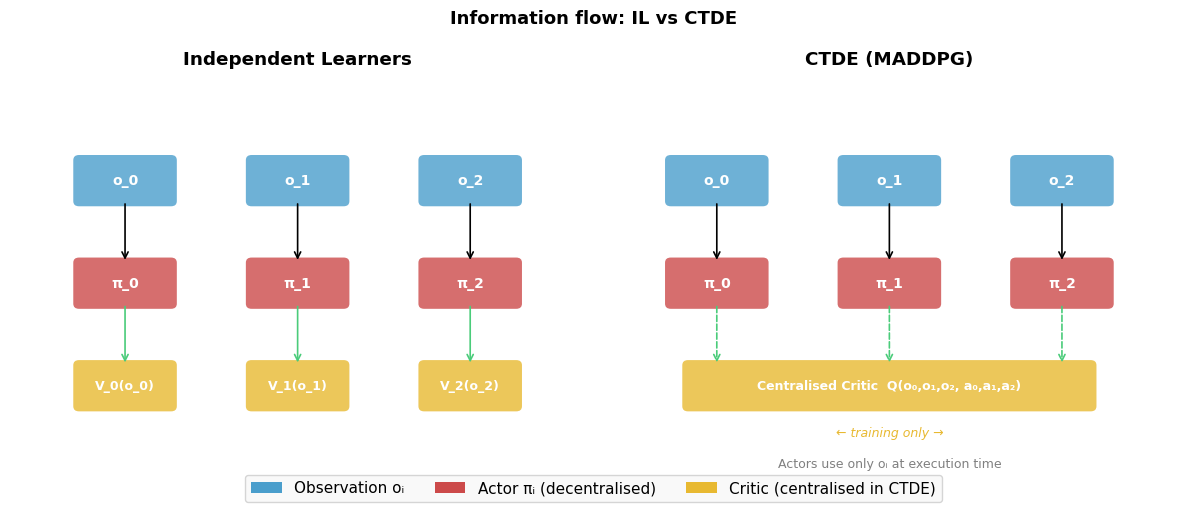

In [ ]:
# ── Diagram: IL vs CTDE information flow ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Information flow: IL vs CTDE", fontsize=13, fontweight='bold')

colors = {"obs": "#4A9ECC", "action": "#4ACC7A",
          "critic": "#E8B931", "actor": "#CC4A4A"}

for ax, (title, use_ctde) in zip(axes, [("Independent Learners", False),
                                         ("CTDE (MADDPG)", True)]):
    ax.set_xlim(0, 10); ax.set_ylim(0, 8)
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

    # Three agent columns
    for i, (xc, ag) in enumerate([(2, "agent 0"), (5, "agent 1"), (8, "agent 2")]):
        # Observation box
        obs_box = mpatches.FancyBboxPatch((xc-0.8, 5.5), 1.6, 0.8,
            boxstyle="round,pad=0.1", fc=colors["obs"], ec="none", alpha=0.8)
        ax.add_patch(obs_box)
        ax.text(xc, 5.9, f"o_{i}", ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

        # Actor box
        act_box = mpatches.FancyBboxPatch((xc-0.8, 3.5), 1.6, 0.8,
            boxstyle="round,pad=0.1", fc=colors["actor"], ec="none", alpha=0.8)
        ax.add_patch(act_box)
        ax.text(xc, 3.9, f"π_{i}", ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

        # Arrow obs → actor
        ax.annotate("", xy=(xc, 4.3), xytext=(xc, 5.5),
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

        # Critic box
        if use_ctde:
            if i == 1:   # single central label
                crit_box = mpatches.FancyBboxPatch((1.5, 1.5), 7.0, 0.8,
                    boxstyle="round,pad=0.1", fc=colors["critic"], ec="none", alpha=0.8)
                ax.add_patch(crit_box)
                ax.text(5, 1.9, "Centralised Critic  Q(o₀,o₁,o₂, a₀,a₁,a₂)",
                        ha='center', va='center', fontsize=9, fontweight='bold',
                        color='white')
            # Arrows to central critic (dashed = training only)
            ax.annotate("", xy=(xc, 2.3), xytext=(xc, 3.5),
                        arrowprops=dict(arrowstyle="->", color=colors["action"],
                                       lw=1.2, linestyle="dashed"))
        else:
            crit_box = mpatches.FancyBboxPatch((xc-0.8, 1.5), 1.6, 0.8,
                boxstyle="round,pad=0.1", fc=colors["critic"], ec="none", alpha=0.8)
            ax.add_patch(crit_box)
            ax.text(xc, 1.9, f"V_{i}(o_{i})", ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
            ax.annotate("", xy=(xc, 2.3), xytext=(xc, 3.5),
                        arrowprops=dict(arrowstyle="->", color=colors["action"],
                                       lw=1.2))

    if use_ctde:
        ax.text(5, 0.9, "← training only →", ha='center', fontsize=9,
                color=colors["critic"], fontstyle='italic')
        ax.text(5, 0.3, "Actors use only oᵢ at execution time",
                ha='center', fontsize=9, color="gray")

legend_elems = [
    mpatches.Patch(fc=colors["obs"],    label="Observation oᵢ"),
    mpatches.Patch(fc=colors["actor"],  label="Actor πᵢ (decentralised)"),
    mpatches.Patch(fc=colors["critic"], label="Critic (centralised in CTDE)"),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


---
## Section 7 — From reward-driven to goal-driven: the GABM bridge

The MARL pipeline we have built — observation, policy, action, reward —
is the right abstraction regardless of how the policy is implemented.

The key insight is that we can **swap the policy implementation** while
keeping the multi-agent interaction structure intact:

```
Gradient descent on R(s,a)   →   Policy from pre-trained language model
Reward shaping               →   Natural language goal description
Anonymous agent              →   Demographic profile (age, income, health...)
No memory                    →   Memory stream + retrieval
```

This is what **Generative Agent-Based Models (GABM)** do:
each "particle" in the system is an LLM conditioned on a persona,
with an explicit memory, a planning module, and a reflection mechanism.

The interaction structure is still a MAS — the environment, the observation,
the action space. Only the policy source changes.

### A toy LLM agent sketch


In [ ]:
# ── Toy illustration: LLM agent interface ────────────────────────────────
# (No actual LLM call — just showing the architecture pattern)

class LLMAgentSketch:
    """
    Minimal sketch of a GABM agent structure.
    In a real system, self.llm would call an API (GPT-4, Claude, etc.)
    """
    def __init__(self, agent_id, persona: dict):
        self.agent_id   = agent_id
        self.persona    = persona       # demographic profile
        self.memory     = []            # memory stream

    def observe(self, percepts: dict):
        """Add new percepts to memory stream."""
        entry = {"time": len(self.memory), "percepts": percepts}
        self.memory.append(entry)

    def _retrieve(self, k=5) -> str:
        """Return the k most recent memory entries as context string."""
        recent = self.memory[-k:] if len(self.memory) >= k else self.memory
        return "\n".join(
            f"[t={e['time']}] " + ", ".join(f"{k}={v}"
            for k, v in e['percepts'].items())
            for e in recent
        )

    def act(self, goal: str) -> str:
        """
        In a real system: call LLM with persona + memory + goal → action.
        Here we just print the prompt that would be sent.
        """
        context = self._retrieve()
        prompt = (
            f"You are {self.persona['name']}, "
            f"age {self.persona['age']}, "
            f"income level: {self.persona['income']}.\n"
            f"Recent observations:\n{context}\n"
            f"Your goal: {goal}\n"
            f"What do you do next? (one short action)"
        )
        print("─" * 60)
        print(f"AGENT {self.agent_id} PROMPT:")
        print(prompt)
        print("─" * 60)
        # In a real system: return llm(prompt)
        return "[LLM response would go here]"


# Example: two synthetic agents with different demographic profiles
agent_alice = LLMAgentSketch(
    agent_id=0,
    persona={"name": "Alice", "age": 32, "income": "middle",
             "health": "healthy", "location": "Bologna"}
)
agent_bob = LLMAgentSketch(
    agent_id=1,
    persona={"name": "Bob", "age": 68, "income": "low",
             "health": "diabetic", "location": "rural Emilia"}
)

# Simulate observations (e.g. from a COVID-19 model)
agent_alice.observe({"new_cases_nearby": 15, "lockdown_level": 1,
                     "vaccination_status": "vaccinated"})
agent_bob.observe({"new_cases_nearby": 3, "lockdown_level": 0,
                   "vaccination_status": "unvaccinated"})

# Query for action
_ = agent_alice.act(goal="Decide whether to go to work today.")


────────────────────────────────────────────────────────────
AGENT 0 PROMPT:
You are Alice, age 32, income level: middle.
Recent observations:
[t=0] new_cases_nearby=15, lockdown_level=1, vaccination_status=vaccinated
Your goal: Decide whether to go to work today.
What do you do next? (one short action)
────────────────────────────────────────────────────────────


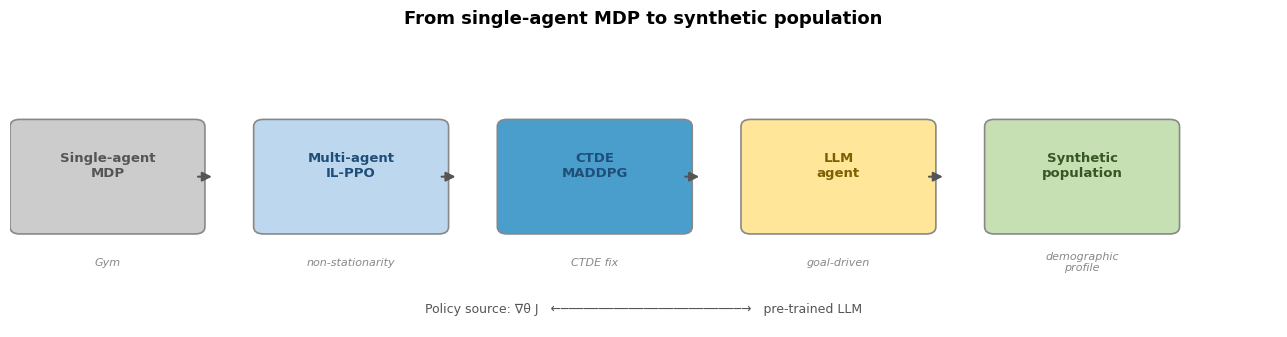

In [ ]:
# ── Full pipeline summary diagram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 4); ax.axis('off')
ax.set_title("From single-agent MDP to synthetic population",
             fontsize=13, fontweight='bold', pad=12)

stages = [
    ("Single-agent\nMDP",        "Gym",             "#CCCCCC", "#555555"),
    ("Multi-agent\nIL-PPO",      "non-stationarity","#BDD7EE", "#1F4E79"),
    ("CTDE\nMADDPG",             "CTDE fix",        "#4A9ECC", "#1F4E79"),
    ("LLM\nagent",               "goal-driven",     "#FFE699", "#7F6000"),
    ("Synthetic\npopulation",    "demographic\nprofile","#C6E0B4","#375623"),
]

xpos = [1.0, 3.5, 6.0, 8.5, 11.0]
for (label, sublabel, fc, tc), x in zip(stages, xpos):
    box = mpatches.FancyBboxPatch((x-0.9, 1.4), 1.8, 1.4,
        boxstyle="round,pad=0.1", fc=fc, ec="#888888", lw=1.2)
    ax.add_patch(box)
    ax.text(x, 2.25, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=tc)
    ax.text(x, 0.9, sublabel, ha='center', va='center',
            fontsize=8, color="#888888", fontstyle='italic')

for x in [1.9, 4.4, 6.9, 9.4]:
    ax.annotate("", xy=(x+0.2, 2.1), xytext=(x, 2.1),
                arrowprops=dict(arrowstyle="-|>", color="#555555",
                               lw=1.5, mutation_scale=14))

ax.text(6.5, 0.2,
        "Policy source: ∇θ J   ←────────────────────────→   pre-trained LLM",
        ha='center', fontsize=9, color="#555555")

plt.tight_layout()
plt.show()


---
## What's next

This notebook has covered the **Week 7** content:

1. **PettingZoo** — the standard MARL environment library
2. **Independent Learners** — the simplest baseline, and why it breaks
3. **Non-stationarity diagnostics** — reward variance, learning curves
4. **CTDE / MADDPG** — the architectural fix: centralised critic at training time
5. **GABM bridge** — from gradient-trained policy to LLM-conditioned persona

**Next sessions** will build on this scaffolding with:
- Generative Agent-Based Models in practice
- Synthetic populations with demographic profiles
- AgentTorch at scale: $10^6$ agents, GPU-accelerated
- Calibration against real census and mobility data

> *The interacting spin system has become intelligent.*
